Shape: (266, 70)
                  Country Name         2022
0                        Aruba     107310.0
1  Africa Eastern and Southern  731821393.0
2                  Afghanistan   40578842.0
3   Africa Western and Central  497387180.0
4                       Angola   35635029.0


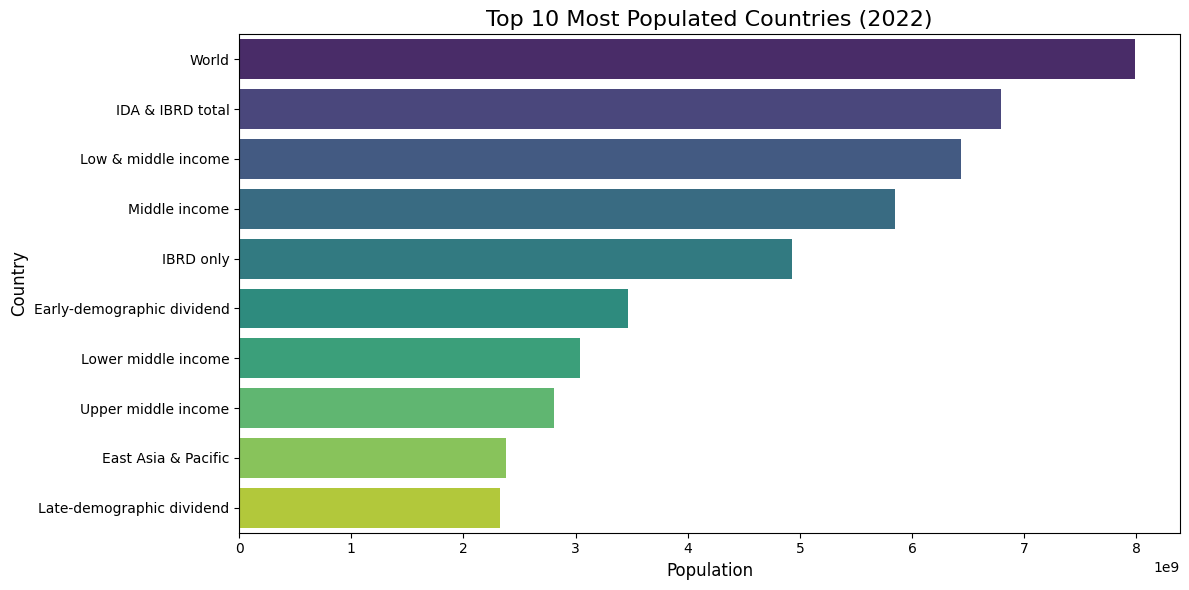

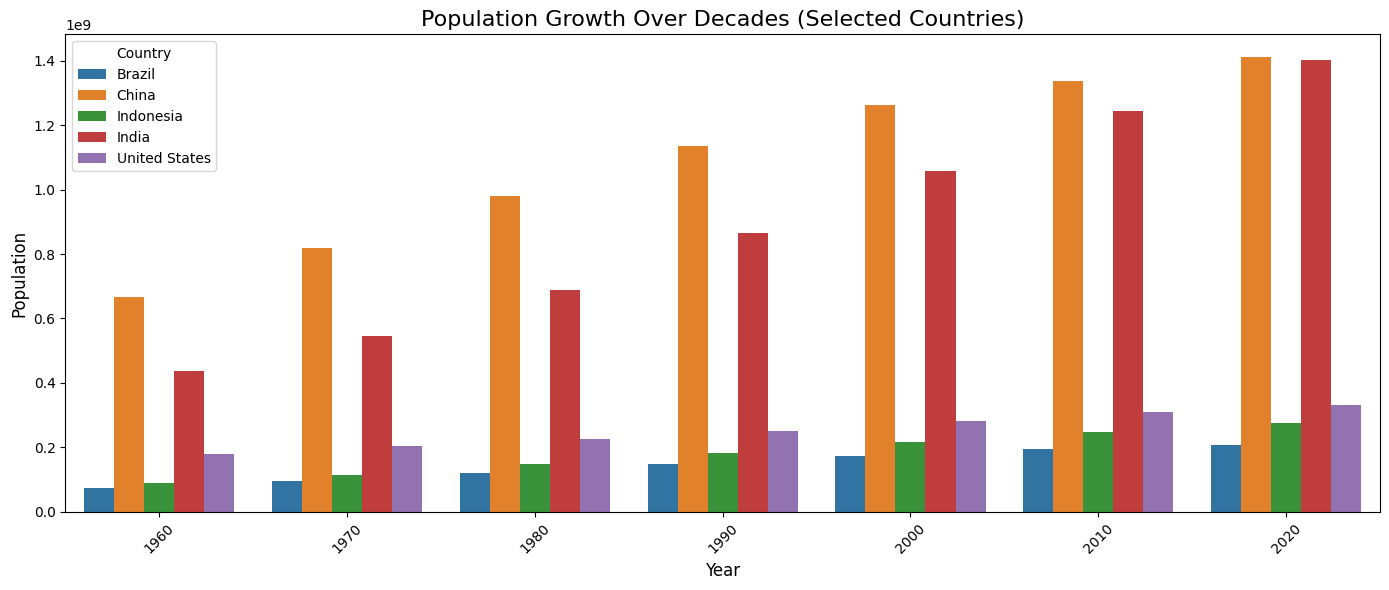

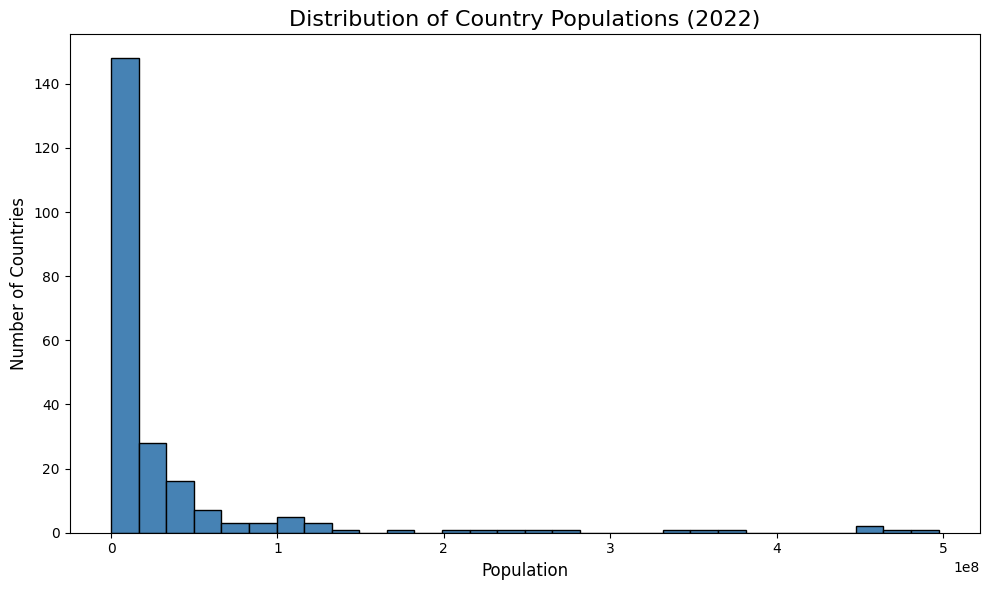

✅ All charts saved successfully!


In [3]:
# ============================================================
# PRODIGY INFOTECH - DATA SCIENCE INTERNSHIP
# Task 01: Population Distribution Visualization
# Dataset: World Bank Population Data
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load Dataset ──────────────────────────────────────────
df = pd.read_csv('/content/API_SP.POP.TOTL_DS2_en_csv_v2_38144.csv', skiprows=4)

print("Shape:", df.shape)
print(df[['Country Name', '2022']].head())

# ── Chart 1: Top 10 Most Populated Countries (Bar Chart) ──
top10 = df[['Country Name', '2022']].dropna()
top10 = top10.sort_values('2022', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='2022', y='Country Name', hue='Country Name', data=top10, palette='viridis', legend=False)
plt.title('Top 10 Most Populated Countries (2022)', fontsize=16)
plt.xlabel('Population', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.savefig('top10_population.png', dpi=150)
plt.show()

# ── Chart 2: Population Growth Over Decades (Grouped Bar) ─
countries = ['India', 'China', 'United States', 'Indonesia', 'Brazil']
years = [str(y) for y in range(1960, 2023, 10)]

filtered = df[df['Country Name'].isin(countries)][['Country Name'] + years]
filtered_melted = filtered.melt(id_vars='Country Name',
                                 var_name='Year',
                                 value_name='Population')

plt.figure(figsize=(14, 6))
sns.barplot(x='Year', y='Population', hue='Country Name', data=filtered_melted)
plt.title('Population Growth Over Decades (Selected Countries)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Population', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Country')
plt.tight_layout()
plt.savefig('population_growth.png', dpi=150)
plt.show()

# ── Chart 3: Histogram - Population Distribution in 2022 ──
pop_2022 = df['2022'].dropna()
pop_2022 = pop_2022[pop_2022 < 5e8]  # exclude outliers for better view

plt.figure(figsize=(10, 6))
plt.hist(pop_2022, bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of Country Populations (2022)', fontsize=16)
plt.xlabel('Population', fontsize=12)
plt.ylabel('Number of Countries', fontsize=12)
plt.tight_layout()
plt.savefig('population_histogram.png', dpi=150)
plt.show()

print("✅ All charts saved successfully!")